# <center> Lecture12 : Logistic Regression </center>  
 
## <center> Instructor: Dr. Hu Chuan-Peng </center> 

## 回顾：贝叶斯视角下的回归模型

在贝叶斯统计框架下，回归模型的构建与检验方法与传统频率学派有所不同。
* 在贝叶斯回归中，模型的参数被视为随机变量，通过数据来更新其概率分布。
* 贝叶斯方法通过对参数的**后验分布**进行推断，从而评估模型的适应性与显著性。
* 这种方法使得我们不仅能得到参数的点估计，还能获得关于这些参数的不确定性的信息。

在之前的课件中，我们以自我优势匹配范式为例，建立了一个简单的线性回归模型：

$$
RT_{sec} \sim \mathcal{N}(\beta_0 + \beta_1 \cdot Label, \sigma^2)
$$

在这个模型中，反应时间（$RT_{sec}$）是一个连续的因变量。




🤔 然而，在许多心理学研究中，另一个常见的因变量是反应是否正确，这通常是一个二分变量（正确/错误）。

当因变量是二分变量时，传统的线性回归模型就不再适用。 在这种情况下，大家可能会想到使用**逻辑回归**（Logistic Regression）模型来探讨因变量为二分变量的情况。

那么，在贝叶斯框架下，我们应该如何构建和处理逻辑回归（Logistic Regression）模型呢？

<div style="padding-bottom: 30px;"></div>

### 以随机点运动任务为例：贝叶斯逻辑回归

接下来，我们以之前介绍过的**随机点运动任务**（Random Motion Dot Task）为例，来理解贝叶斯逻辑回归模型的应用。

* 在这个实验中，参与者观察屏幕上随机运动的点，这些点的运动方向具有一定的一致性（即大部分点朝某一方向移动）。
* 参与者的任务是判断这些点的主要移动方向（例如，向左还是向右）。

实验的设计可以控制点的运动一致性（如10%或40%），从而影响参与者作出正确决策的难度。

<center>  
    <table>  
            <tr>  
                <td><img src="https://cdn.kesci.com/upload/sjwnyi477j.gif?imageView2/0/w/400/h/400" alt=""></td>  
                <td><img src="https://cdn.kesci.com/upload/sjwnyt1yq4.gif?imageView2/0/w/400/h/400" alt=""></td>  
            </tr>  
            <tr>  
                <td>一致性10%</td>  
                <td>一致性40%</td>  
            </tr>  
    </table>  
</center>  

**和之前的内容不同，本次课我们将研究点的运动一致性与判断是否正确之间的关系**：

1. **自变量：** 点的运动一致性（10% 一致性 与 40% 一致性）；
2. **因变量：** 判断是否正确（即被试是否准确判断了点的主要运动方向，1代表反应正确，0代表反应错误）。

<div style="padding-bottom: 30px;"></div>

以Evans et al.（2020, Exp. 1） 的数据为例进行探索。

> Evans, N. J., Hawkins, G. E., & Brown, S. D. (2020). The role of passing time in decision-making. Journal of Experimental Psychology: Learning, Memory, and Cognition, 46(2), 316–326. https://doi.org/10.1037/xlm0000725  


In [1]:
# 导入 pymc 模型包，和 arviz 等分析工具 
import pymc as pm
import arviz as az
import seaborn as sns
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import ipywidgets

# 忽略不必要的警告
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('2024/data/evans2020JExpPsycholLearn_exp1_full_data.csv')

# 使用 pandas 导入示例数据
# try:
#   df = pd.read_csv("/home/mw/input/bayes3797/evans2020JExpPsycholLearn_exp1_full_data.csv") 
# except:
#   df = pd.read_csv('data/evans2020JExpPsycholLearn_exp1_full_data.csv')

# 筛选编号为 31727 的数据，并且筛选出两个不同的 percentCoherence
df_clean = df[(df['subject'] == 31727) & (df['percentCoherence'].isin([10, 40]))]
df_clean  = df_clean[["subject", "percentCoherence", "correct"]]

df_clean

,subject,percentCoherence,correct
0,31727,10,1
1,31727,40,0
3,31727,40,1
6,31727,10,1
7,31727,10,1
...,...,...,...
1095,31727,10,1
1097,31727,10,1
1098,31727,10,1
1099,31727,40,1


In [3]:
df_clean.groupby("percentCoherence").correct.mean()

percentCoherence
10    0.686047
40    0.926316
Name: correct, dtype: float64

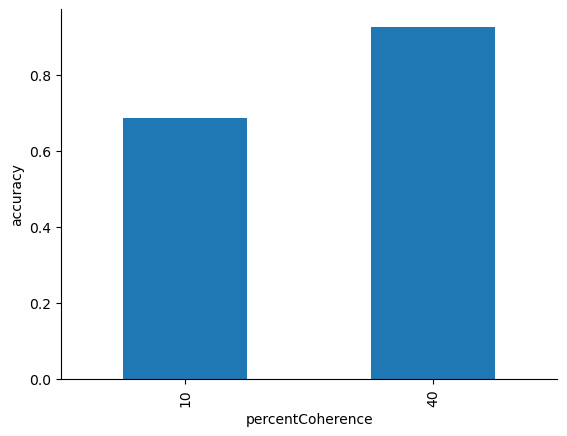

In [4]:
# 因变量分布
ax = df_clean.groupby("percentCoherence").correct.mean().plot.bar()

ax.set_ylabel("accuracy")
sns.despine()
plt.show()

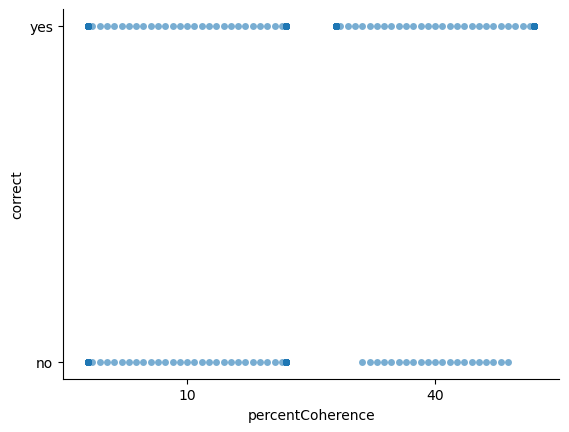

In [5]:
# 绘制散点图
sns.swarmplot(data=df_clean,
                x="percentCoherence",
                y="correct",
                alpha=0.6)
# plt.xlabel("percentCoherence")
plt.xticks([0, 1],['10', '40'])
plt.yticks([0, 1],['no', 'yes'])
sns.despine()

## Odds & probability  

在观察数据时可以发现，因变量的取值仅为0或1，而相比于可视化每个数据点，将数据描述或可视化为正确率(概率)会更加方便理解。  

并且，为了建立自变量与因变量的线性模型，我们需要引入概念：**概率**和**发生比(odds)**。 以此说明，离散数据点(例如，0 和 1)和概率之间的关系。

### 概率(probability)  

当不考虑自变量时，不考虑自变量时，因变量"correct"为正确的概率为 0.812 。

当考虑自变量“percentCoherence”时：  
  * 当“percentCoherence” 为10 ，"correct"为“是”的概率为 0.686;  
  * 当“percentCoherence” 为40，"correct"为“是”的概率为 0.926。
  
* 这表明，随着点的运动一致性增加，正确率也提高了。

In [6]:
print(f"因变量“correct”为“是”的概率为{df_clean.correct.mean():.3f}")

因变量“correct”为“是”的概率为0.812


In [7]:
print(f"当“percentCoherence” 为10 ，'correct'为“是”的概率为{df_clean[df_clean.percentCoherence == 10].correct.mean():.3f}")
print(f"当“percentCoherence” 为40，'correct'为“是”的概率为{df_clean[df_clean.percentCoherence == 40].correct.mean():.3f}")

当“percentCoherence” 为10 ，'correct'为“是”的概率为0.686
当“percentCoherence” 为40，'correct'为“是”的概率为0.926


### 发生率(odds)

与概率不同，发生率(odds)描述的是 **事件发生概率** 与 **事件不发生概率**之比 ，而概率则描述了事件发生的绝对可能性。

我们用“明天是否会下雨”的例子来进行说明。

在这个例子中，$\pi$为因变量$Y$发生的概率  

$$  
\begin{equation}  
\text{odds} = \frac{\pi}{1-\pi} \;\;,\;\;\;  
\pi = \frac{\text{odds}}{1 + \text{odds}}  
\end{equation}  
$$  

* 比如，明天下雨发生的概率是$\pi = 2/3$，则明天不下雨的概率为$1 - \pi = 1/3$  

    * 在这个例子中，将 $\pi$ 带入公式得到发生比 odds 为2，明天下雨的可能性是不下雨可能性的两倍  
    
    * $\pi$的值在$(0,1)$之间，odds的范围则可以是$(0,+\infty)$  
$$  
\text{odds of rain } = \frac{2/3}{1-2/3} = 2  
$$  



事件的发生概率$\pi \in [0,1]$，事件对应的发生比为$\;\;\;\pi / (1-\pi) \in [0, \infty)$  

> 将发生比与1进行比较来衡量事件发生的不确定性：  

1. 当事件发生的概率$\pi < 0.5$时，事件的发生比小于1  

2. 当事件发生的概率$\pi = 0.5$时，事件的发生比为等于1  

3. 当事件发生的概率$\pi > 0.5$时，事件的发生比为大于1

## 选择合适的分布  

🤔 在贝叶斯框架下，重要的问题是如何通过概率分布来描述随机变量。现在我们其实有两个问题？  

1. 选择哪种分布描述概率和发生比？
2. 对于离散随机变量 (如0和1)，如何选择合适的分布？

此外，我们需要考虑如何丝滑地从一个分布转移到另一个分布？ 即如何将离散随机变量建模为概率和发生比？

### 回顾：Gamma分布与Beta分布  

   * 在lec3中，我们介绍了Beta分布，用来假设随机点运动任务中的正确率$\pi$服从Beta分布，$\pi$的取值范围满足[0,1]  

   * 在lec5中，我们介绍了Gamma分布，Gamma分布是一种连续的概率分布，用于描述等待时间直到第$k$个事件发生的时间长度

通过这两种分布的对比，我们可以看到，Beta分布适合描述随机点运动任务中的正确率$\pi$，因为它的定义域是$[0,1]$。

另一方面，考虑到事件发生比的范围是$[0, \infty)$，Gamma分布则可以用来描述随机点运动任务中的事件发生比。

<table>  
	<tr>  
         <td>Beta分布</td>  
         <td><img src="https://cdn.kesci.com/upload/s50phv2jbg.png?imageView2/0/w/960/h/960" alt="" width="600"> </td>  
   </tr>  
   <tr>  
         <td>Gamma分布</td>  
         <td><img src="https://cdn.kesci.com/upload/s50pi6t34t.png?imageView2/0/w/960/h/960" alt="" width="600"> </td>  
   </tr>  
</table>  


<div style="padding-bottom: 30px;"></div>

### 伯努利(Bernoulli)分布


由于 $Y_i$ 是一个离散变量，只有两个取值：0或1，可知Gamma分布与Beta分布都不是合适的分布  

更加适合变量 $Y_i$ 的分布为伯努利(Bernoulli)分布，该分布只有两个取值0或1。

**伯努利试验**  

要了解伯努利分布，我们需要知道伯努利试验。  
我们使用抛硬币的例子来演示伯努利试验。  

* 假设我们抛一枚硬币，而该硬币正面朝上的概率是 $p$  
* 那么抛一枚硬币的结果要不是正面朝上(1)，要不就是反面朝上(0)；  
* 其中正面朝上发生的概率是$p$，反面朝上发生的概率是$1=p$  

用公式表示为：  

$$  
f(x) = \left\{\begin{matrix} p & if \: x = 1\\  1 - p & if \: x = 0 \end{matrix}\right. \;\;\; \text{ for } x \in \{ 0,1\} ,\;\;\;0 \leq p  \leq 1  
$$

![Image Name](https://cdn.kesci.com/upload/snyig2mn38.png?imageView2/0/w/640/h/960)


我们可以使用`np.random.binomial`来模拟一次伯努利实验的结果

In [8]:
result = np.random.binomial(n=1, p=0.7, size=1)
print(f"硬币朝向为：{result}")

硬币朝向为：[1]


**伯努利分布**  

* 伯努利分布常常用于描述一次单独的二元实验，例如投硬币的结果  

* 如果随机变量 $X$ 服从伯努利分布，可以表示为 $X \sim \text{Bernoulli}(p)$，其中 $p$ 是成功的概率  

* 伯努利分布的概率质量函数为：  

    * 其中，X是伯努利随机变量，x是取值为0或1的观察值，p是成功的概率。这个函数表示了在一次伯努利试验中，观察到特定取值x的概率。  

$$  
P(X = x) = p^x  (1 - p)^{(1 - x)}\;\;\; \text{ for } x \in \{ 0,1\}  
$$  





In [9]:
# 定义伯努利分布的绘图函数
def plot_bernoulli():

    def bernoulli(p):
        x = [0,1]
        plt.bar(x, st.bernoulli.pmf(x, p), label=f'bernoulli({p})')
        plt.xticks([0, 1])
        sns.despine()
        plt.title("Bernoulli Distribution")
        plt.legend()

    # 使用 ipywidgets 进行交互式绘图
    ipywidgets.interact(bernoulli, p=(0,1,0.1))
    plt.show()

plot_bernoulli()

interactive(children=(FloatSlider(value=0.0, description='p', max=1.0), Output()), _dom_classes=('widget-inter…

#### 真实数据中的伯努利分布、与线性关系

在我们的研究示例中，
* 因变量“correct”是一个二分类变量，表示被试是否获得正确反应。
* 我们考虑的自变量“percentCoherence”是一个连续变量，表示被试的刺激强度 (percentCoherence 或 motion strength)。
* 我们知道，随着刺激强度的增加，被试获得正确反应的概率(正确率)也会增加。因此，我们可以假设“correct”与“percentCoherence”之间存在线性关系。
* 然而，真实的数据是离散的二分变量，而不是连续的正确率，因此我们需要对数据进行转换。

<center> <img src='https://cdn.kesci.com/upload/skeayxhg1s.png?imageView2/0/w/700'> </center>  

> Shooshtari, S. V., Sadrabadi, J. E., Azizi, Z., & Ebrahimpour, R. (2019). Confidence representation of perceptual decision by EEG and eye data in a random dot motion task. Neuroscience, 406, 510–527. https://doi.org/10.1016/j.neuroscience.2019.03.031  


因此，转化的思路在于，在每个刺激强度下，被试获得正确反应的概率可以看作是一个伯努利分布，即 $Y_i | \pi_i \sim \text{Bern}(\pi_i)$，其中 $\pi_i$ 是在刺激强度 $x_i$ 下被试获得正确反应的概率。

* 曲线上的每一个点，都服从伯努利分布 $Y_i | \pi_i \sim \text{Bern}(\pi_i)$  
* 我们知道，由于因变量为二分类变量，并不满足线性关系的假设，即因变量需要是连续的且满足正态分布的，显然我们例子中的因变量“correct”并不满足这一假设。
* 因此，我们需要对因变量进行一定的转换，建立线性关系。

为了方便演示和建模，我们仅考虑两种刺激强度(percentCoherence)下的数据，即 $x = 0.1$ 和 $x = 0.4$。

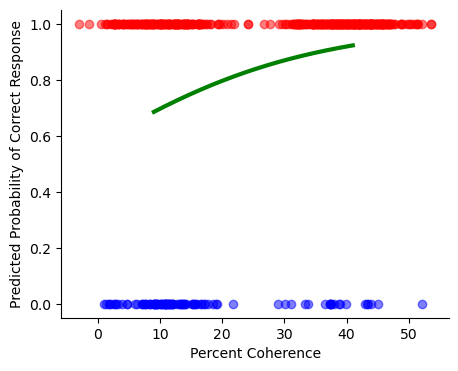

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import seaborn as sns

# 这里假设 df_clean 是你预处理好的 DataFrame

X = df_clean["percentCoherence"]
y = df_clean["correct"]

# 为了增加散点的 jitter，我们给 X 添加一些小的随机噪声
X_jittered = X + np.random.normal(loc=0, scale=5, size=X.shape)

# 使用逻辑回归模型进行拟合
log_reg = LogisticRegression()
log_reg.fit(X_jittered.values.reshape(-1, 1), y)

# 预测逻辑回归线
X_line = np.linspace(X.min()-1, X.max()+1, 1000)
y_line = log_reg.predict_proba(X_line.reshape(-1, 1))[:, 1]

# 绘制逻辑回归线和散点图
plt.figure(figsize=(5, 4))
plt.scatter(X_jittered[y == 0], y[y == 0], color='blue', alpha=0.5, label='Class 0')
plt.scatter(X_jittered[y == 1], y[y == 1], color='red', alpha=0.5, label='Class 1')
plt.plot(X_line, y_line, color='green', linewidth=3, label='Logistic Regression Line')  # 加粗回归线
plt.xlabel('Percent Coherence')
plt.ylabel('Predicted Probability of Correct Response')
sns.despine()
plt.show()


### 补充知识：对于概率和发生比适用的更多分布

|分布类型|描述概率|描述发生比|适用情况说明|
|---|---|---|---|
|二项分布|是|否|描述n次独立伯努利试验中成功次数的概率分布。|
|贝塔分布|是|是|描述伯努利试验中成功概率的先验分布，也可以用来描述发生比。|
|正态分布|否|否|描述连续随机变量的概率分布，不直接用于描述概率或发生比，但可以用于近似。|
|对数正态分布|否|是|描述正态分布变量取对数后的分布，常用于描述正比于发生比的数据。|
|泊松分布|是|否|描述在固定时间或空间内发生某事件的次数的概率分布。|
|伽马分布|否|是|描述等待时间的分布，常用于作为泊松分布中事件发生率的先验分布，因此可以用来描述发生比。|
|负二项分布|是|否|描述在获得r次成功之前经历n次试验的概率分布，适用于成功概率不固定的情况。|
|多项分布|是|否|描述多项式试验中各种结果次数的概率分布。|
|Dirichlet分布|是|是|描述多项分布中各种结果概率的先验分布，也可以用来描述发生比。|

### 补充知识：伯努利分布与二项分布的关系

伯努利分布是一个离散型概率分布，它描述了一次试验的结果只有两种可能性的情况，比如成功和失败、是和非等。伯努利分布由一个参数p控制，表示成功的概率。记作X ~ Bernoulli(p)，其中X为随机变量，p为成功的概率。  

二项分布是一种离散型概率分布，它描述了在n次相互独立的伯努利试验中，成功次数的概率分布，记作X ~ Binomial(n, p)。其中X为随机变量，n为试验次数，p为每次实验成功的概率。  

* 假设我们进行了10次硬币的投掷，每次投掷的结果只有两种可能，正面或反面。每次投掷正面朝上的概率是p。  

* 每次投掷的结果服从伯努利分布。  

* 10次投掷中，正面朝上可能为 0，1，2，3，...，10。正面朝上次数服从的概率分布为二项分布。  


| 分布     | 描述                           | 参数                    | 随机变量    |  
|---------|------------------------------|-----------------------|------------|  
| 伯努利分布 | 描述一次试验的结果只有两种可能性   | 成功概率 p              | X ~ Bernoulli(p) |  
| 二项分布  | 描述在 n 次独立的伯努利试验中成功次数的概率分布 | 试验次数 n, 成功概率 p | X ~ Binomial(n, p) |

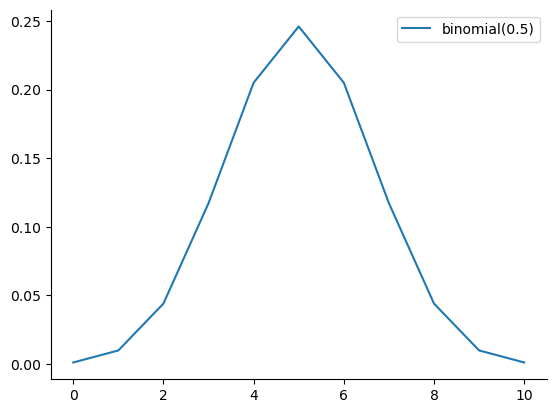

In [11]:
# 定义绘制二项分布的函数
def plot_binomial(n,p):

  x = np.arange(0, n+1, 1)
  plt.plot(x, st.binom(n,p).pmf(x), label=f'binomial({p})')

  plt.legend()
  sns.despine()
  plt.show()

plot_binomial(10,0.5)

**使用伯努利概率模型来拟合因变量**  

可以从上图发现，伯努利分布和数据因变量分布类似，因此，我们可以尝试使用伯努利分布来描述被试作出正确判断的情况。  

* 我们使用伯努利概率模型来拟合事件 Y 的取值，其中 $\pi_i$ 表示事件 Y 发生的可能性   $Y_i | \pi_i \sim Bern(\pi_i)$  

* 事件 Y 发生的均值与 $\pi_i$ 相等  $E(Y_i|\pi_i) = \pi_i$  


## 选择连接函数(link function)  

知道了如何对离散变量(例如，是否正确)和连续变量(例如，概率或发生比)设置分布之后，接下来我们需要选择一个连接函数（link function），将这两个模型连接起来。

* 现在我们可以借助 回答为“是”的概率，以及回答为“是”的发生比，来对自变量“percentCoherence”和因变量“correct”建立线性关系  

* 由于因变量是一个二分变量，我们使用 logistic回归模型，它是广义线性模型中的一种。
  

![Image Name](https://cdn.kesci.com/upload/snwiwe9i1q.png?imageView2/0/w/640/h/960)




* 在广义线性模型中，我们需要找到一个连接函数$g(\cdot)$，使得参数g($\pi_i$)可以被表示为自变量$X_{i1}$的线性组合  

    * 🤔以下哪一个是合理的连接函数？  

    1. $\pi_i = \beta_0 + \beta_1 X_{i1}$  

    2.  $\log(\pi_i) = \beta_0 + \beta_1 X_{i1}$  

    3.  $\text{odds}_i = \beta_0 + \beta_1 X_{i1}$  

    4.  $\log(\text{odds}_i) = \beta_0 + \beta_1 X_{i1}$  

* 我们可以比较等式左右两边的取值范围是否一致，并将上述连接函数进行可视化  

| 等式左边    | 取值范围     | 等式右边      | 取值范围    |   
| -------- | ----------------- | ---------------- | ------------------ |  
| $\pi_i$  |  $(0,1)$    | $\beta_0 + \beta_1 X_{i1}$  | $(-\infty, +\infty)$  |  
| $\log(\pi_i)$  |  $(-\infty,0)$     | $\beta_0 + \beta_1 X_{i1}$  | $(-\infty, +\infty)$   |  
| ${odds}_i$  |  $(0,+\infty)$    | $\beta_0 + \beta_1 X_{i1}$  | $(-\infty, +\infty)$   |  
| $\log({odds}_i)$  |$(-\infty, -+\infty)$  | $\beta_0 + \beta_1 X_{i1}$  | $(-\infty, +\infty)$   |  

![Image Name](https://cdn.kesci.com/upload/snyjmb20r4.png?imageView2/0/w/960/h/960)


### 公式中各参数的意义  

$$  
\log(\text{odds}) = \log\left(\frac{\pi}{1-\pi}\right) = \beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p  
$$  

也可以写成：$\text{odds} = e^{\beta_0 + \beta_1 X_{1} +\cdots + \beta_p X_p}$  

$\beta_0$ 是截距项，也称为 常数项，它表示当所有自变量（$X_1, X_2, \dots, X_p$）都为零时，log（odds） 的基线值。换句话说，$\beta_0$ 表示模型在无任何预测变量影响时的log（odds）。

$\beta_1, \beta_2, \dots, \beta_p$ 是回归系数，分别表示每个预测变量（$X_1, X_2, \dots, X_p$）对 log（odds）的影响。每个 $\beta_i$ 表示对应自变量 $X_i$ 增加一个单位时，log（odds）变化的大小。

> Gelman, A., &#38; Hill, J. (2006). Data Analysis Using Regression and Multilevel/Hierarchical Models. Cambridge: Cambridge University Press. 

* $\beta_0$  

    * 当$(X_1,X_2,\ldots,X_p) = 0$时，$\text{odds} = e^{\beta_0}$，即$e^{\beta_0}$表示当所有自变量为0时，事件的发生比  

* $\beta_1$  

    * $\beta_1 = \log(\text{odds}_{x+1}) - \log(\text{odds}_x)\;\;\;$ → $\;\;\; e^{\beta_1} = \frac{\text{odds}_{x+1}}{\text{odds}_x}$  

    * 当其他自变量保持不变时，$X_1$每增加一个单位（从$x$ → $x+1$），$e^{\beta_1}$表示事件发生比的倍数变化  


* 计算  

    $\log\left(\frac{\pi_i}{1 - \pi_i}\right) = \beta_0 + \beta_1 X_{i1}\;\;\;$ →  $\;\;\;\frac{\pi_i}{1-\pi_i} = e^{\beta_0 + \beta_1 X_{i1}}\;\;\;$ →  $\;\;\;\pi_i = \frac{e^{\beta_0 + \beta_1 X_{i1}}}{1 + e^{\beta_0 + \beta_1 X_{i1}}}$  

## 模型定义  

现在，我们已经了解了逻辑回归模型的基本结构，我们可以开始定义模型了。
* 我们需要确定变量类型和分布。
* 需要根据连接函数（link function）来设置转化参数。
* 并且为转化后的参数设置先验分布。

$$  
\begin{array}{lcrl}  
\text{data:} & \hspace{.01in} & Y_i|\beta_0,\beta_1 & \stackrel{ind}{\sim} \text{Bern}(\pi_i) \;\; \text{ with } \;\; \pi_i = \frac{e^{\beta_0 + \beta_1 X_{i1}}}{1 + e^{\beta_0 + \beta_1 X_{i1}}} \\  
\text{priors:} & & \beta_{0}  &  \sim N\left(0, 10^2 \right)  \\  
               & & \beta_1  & \sim N\left(0, 10^2 \right)\\  
\end{array}  
$$

注意：这里的参数先验是经过 logit 转后后的值，而不是概率。 因此，我们需要根据先验预测检验来确定先验分布参数设置是否正确。


In [18]:
# 数据准备
Treatment_Coding,_ = df_clean['percentCoherence'].factorize() # 适用 treatment 编码
y = df_clean['correct'].values  # 目标变量

# 模型构建
with pm.Model() as log_model1:

    # 添加数据，方便后续绘图
    pm.MutableData("percentCoherence", df_clean['percentCoherence'])

    # 设置先验
    # 通常我们会为截距和系数设置正态分布的先验
    intercept = pm.Normal('beta_0', mu=0, sigma=10)
    coefficient = pm.Normal('beta_1', mu=0, sigma=10)
    
    # 线性预测
    linear_predictor = intercept + coefficient * Treatment_Coding
    
    # 似然函数
    # 使用逻辑函数将线性预测转换为概率
    # 方法一：自行进行 logit link 转换
    pi = pm.Deterministic('pi', pm.math.invlogit(linear_predictor))
    likelihood = pm.Bernoulli('likelihood', p=pi, observed=y)
    # 方法二：直接使用 logit_p 进行转换
    # likelihood = pm.Bernoulli('likelihood', logit_p=linear_predictor, observed=y)

注意代码中使用了 `pm.math.invlogit` 函数，它相当于计算了 Logistic sigmoid function，即 $1 / (1 + e^{-\mu})$。

为了方便我们自行进行转化，我们可以自行定义这个函数，如下：

In [19]:
def inv_logit(x):
    return np.exp(x) / (1 + np.exp(x))

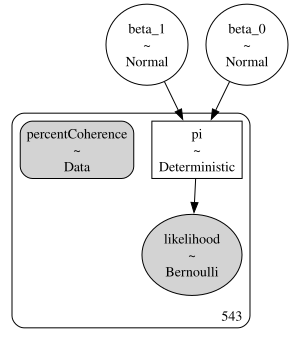

In [20]:
# 可视化模型（贝叶斯变量因果图）
# 我们使用 pymc 自带的 `model_to_graphviz` 方法来可视化模型中各变量的因果关系。
pm.model_to_graphviz(log_model1)

### 先验预测检验  

使用`pm.sample_prior_predictive`进行先验预测检验，来查看由当前先验组合生成的$\pi$是否都在$(0-1)$范围内  


In [21]:
log1_prior = pm.sample_prior_predictive(samples=50, 
                                          model=log_model1,
                                          random_seed=84735)

Sampling: [beta_0, beta_1, likelihood]


* 在模型定义中我们已经对`pi`进行定义，因此`pm.sample_prior_predictive`就会自动生成对`pi`的预测  

* 该预测储存在`prior`中  

* 我们设置抽样数为50，这体现在维度`draw`中  

* 结合循环，使用`sns.lineplot`绘制出每个回避分数对应的$\pi$值并连接成光滑的曲线

In [22]:
log1_prior

Inference data with groups:
	> prior
	> prior_predictive
	> observed_data
	> constant_data

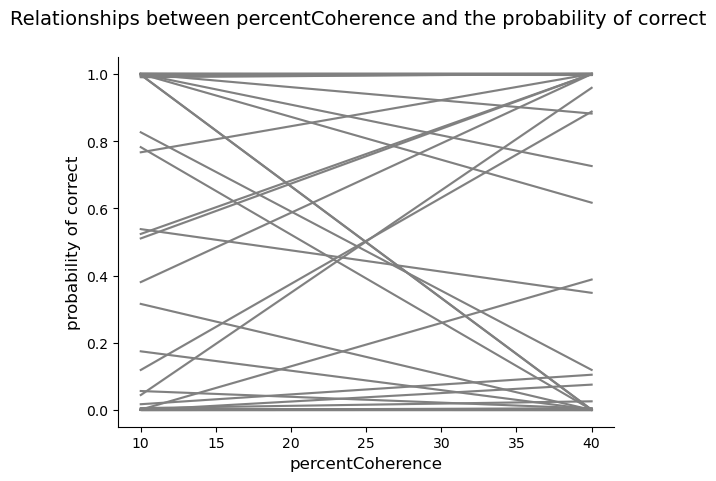

In [23]:
#对于一次抽样，可以绘制出一条曲线，结合循环绘制出50条曲线
for i in range(log1_prior.prior.dims["draw"]):
    sns.lineplot(x = log1_prior.constant_data["percentCoherence"],
                y = log1_prior.prior["pi"].stack(sample=("chain", "draw"))[:,i], c="grey" )

#设置x、y轴标题和总标题    
plt.xlabel("percentCoherence",
           fontsize=12)
plt.ylabel("probability of correct",
           fontsize=12)
plt.suptitle("Relationships between percentCoherence and the probability of correct",
           fontsize=14)
sns.despine()
plt.show()

## MCMC采样 & 模型诊断

In [24]:
#===========================
#     注意！！！以下代码可能需要运行35s~1分钟左右
#===========================
with log_model1:
    # 模型编译和采样
    log_model1_trace = pm.sample(draws=5000,                 
                                tune=1000,                  
                                chains=4,                     
                                discard_tuned_samples=True, 
                                random_seed=84735)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta_1]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 3 seconds.


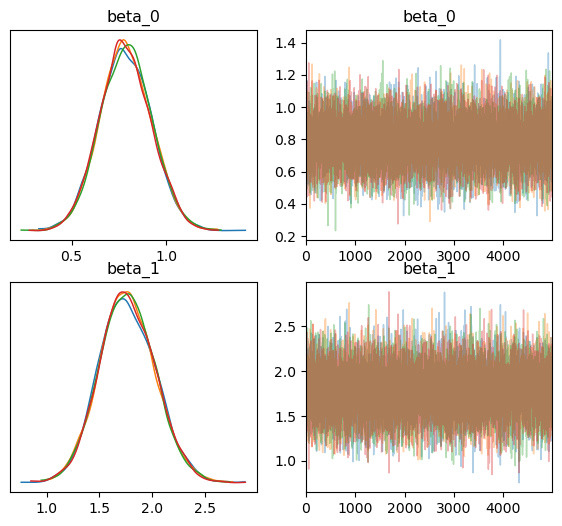

In [25]:
az.plot_trace(log_model1_trace,
              var_names=["beta_0","beta_1"],
              figsize=(7, 6),
              compact=False)
plt.show()

### 后验参数解释  

以下的结果显示：  
- $\beta_0 = 0.786$，那么 $e^{\beta_0} = 2.195$， $X_{i1} = 0$ 时（例如，$X_{i1}$ 没有影响），则事件发生的 odds 为 $e^{\beta_0} 为 2.195$。  
- $\beta_1 = 1.765$， $e^{\beta_1} = 5.859$， $X_{i1}$ 每增加 1 个单位，odds 将增加 $e^{\beta_1} 的 5.859$ 倍
- 然而，$\beta_1$ 的94%HDI包括0，说明点的一致性方向概率不能有效预测判断是否正确的概率。 

In [26]:
fitted_parameters = az.summary(log_model1_trace, var_names=["beta_0","beta_1"])
fitted_parameters

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_0,0.786,0.136,0.535,1.041,0.001,0.001,11989.0,12901.0,1.0
beta_1,1.765,0.264,1.264,2.254,0.002,0.002,11381.0,12021.0,1.0


为了将发生比转换为概率，我们需要计算适用逆运算，如下：

In [27]:
def inv_logit(log_odds):
    return np.exp(log_odds) / (1 + np.exp(log_odds))

p_coh10 = inv_logit( fitted_parameters.loc["beta_0", "mean"])
p_coh40 = inv_logit( 
    fitted_parameters.loc["beta_1", "mean"] + \
        fitted_parameters.loc["beta_1", "mean"]
)

print(f"p(coherence=10) = {p_coh10:.3f}", f"p(coherence=40) = {p_coh40:.3f}")

p(coherence=10) = 0.687 p(coherence=40) = 0.972


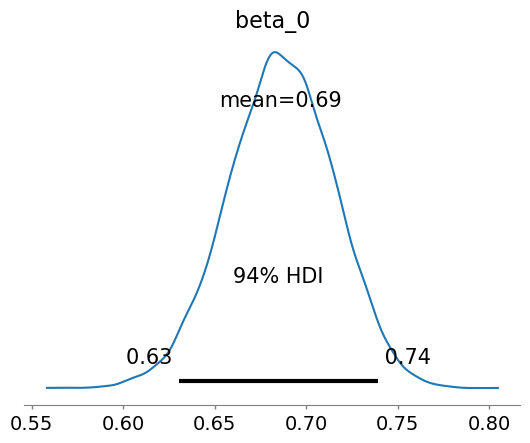

In [28]:
# 通过 inv_logit 将 beta 参数进行转换
az.plot_posterior(log_model1_trace, var_names=["beta_0"], transform = inv_logit)
plt.show()

## 后验回归模型  

### 绘制后验预测回归线  

* 和先验预测模型类似的，通过MCMC采样，也同样生成了对$\pi$的估计，储存在`posterior`中  

* 有4条马尔科夫链，每条链上的采样数为2000，所以对于每一个x，都生成了20000个预测值$\pi$，这样就对应着20000条后验预测回归线  

* 这里我们只需要画出100条即可

In [29]:
log_model1_trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

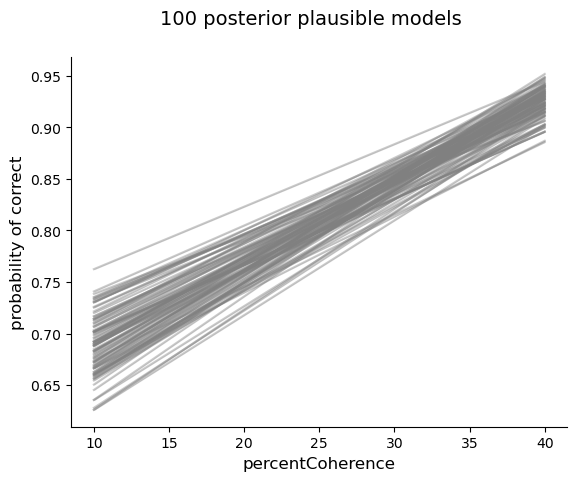

In [31]:
#对于一次抽样，可以绘制出一条曲线，结合循环绘制出50条曲线
for i in range(100):
    sns.lineplot(x = log_model1_trace.constant_data["percentCoherence"],
            y = log_model1_trace.posterior["pi"].stack(sample=("chain", "draw"))[:,i], 
            c="grey",
            alpha=0.4)
    
#设置x、y轴标题和总标题    
plt.xlabel("percentCoherence",
           fontsize=12)
plt.ylabel("probability of correct",
           fontsize=12)
plt.suptitle("100 posterior plausible models",
           fontsize=14)
sns.despine()
plt.show()

## 对新数据进行预测&分类  

* 除了对当前数据结果做出解释，我们也可以使用当前的参数预测值，对新数据做出预测  

* 比如，当“percentCoherence”位于一个标准差时，即 $X_{i1}=1$时，被试是否判断正确  


$$  
Y | \beta_0, \beta_1 \sim \text{Bern}(\pi) \;\; \text{ with } \;\; \log\left( \frac{\pi}{1-\pi}\right) = \beta_0 + \beta_1 * 1  
$$  

* 我们使用`pm.set_data`传入新的数据，使用`pm.sample_posterior_predictive`对新数据生成后验预测值  
    * 假设我们传入的数据是(X=1, Y=0)

In [32]:
with log_model1:
    
    log_model1_ppc = pm.sample_posterior_predictive(
        log_model1_trace,
        predictions=True,
        extend_inferencedata=True,
        random_seed=84735
    )

Sampling: [likelihood]


Output()

In [33]:
log_model1_ppc

Inference data with groups:
	> posterior
	> predictions
	> sample_stats
	> observed_data
	> constant_data
	> predictions_constant_data

* 预测结果储存在`prediction.predictions`中  

* 我们可以将预测结果提取出来，并统计其中 0 和 1的个数

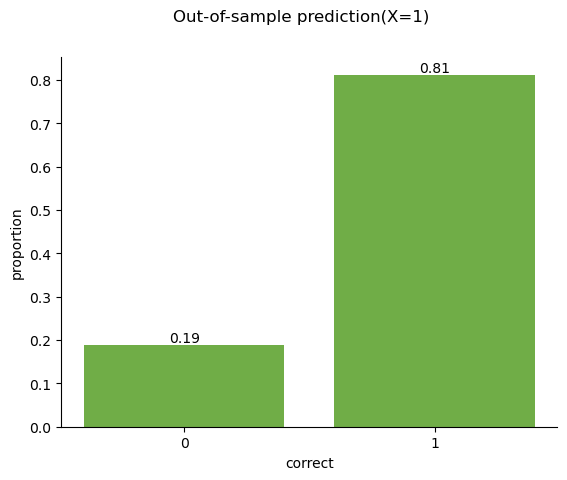

In [34]:
# 提取储存在 predicitons中的预测值
y_pred = log_model1_ppc.predictions["likelihood"].stack(sample=("chain","draw","likelihood_dim_2")).values

# 统计其中0和1的个数，并除以总数，得到0和1对应的比例值
y_pred_freq = np.bincount(y_pred)/len(y_pred)

#绘制柱状图
bars = plt.bar([0, 1], y_pred_freq, color="#70AD47")

#用于在柱状图上标明比例值
for bar, freq in zip(bars, y_pred_freq):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{freq:.2f}", ha='center', va='bottom')

#对刻度、标题、坐标轴标题进行设置
plt.xticks([0, 1])
plt.suptitle("Out-of-sample prediction(X=1)")
plt.xlabel("correct")
plt.ylabel("proportion")
sns.despine()

### 分类标准(classification cut-off)  

* 我们看到在对新结果的预测中，有66%的可能将其预测为0，有34%的可能将其预测为1  

    * 🤔那么我们应该如何确定预测值是 0 还是 1  

* 在得到预测值后，我们需要确定一个分类标准$c$，比如50-50 cut-off  

    * 如果超过50%的结果显示$Y=1$，我们就将$Y$归类为1(正确)  
    
    * 否则将$Y$归类为0  

* 总结：  
    
    * 假设$Y$是一个二分变量，1或0，从长度为N的马尔科夫链上，我们得出了$Y$的$N$个后验预测值，$\left(Y_{new}^{(1)}, Y_{new}^{(2)}, \ldots, Y_{new}^{(N)}\right)$，$p$ 代表在这些预测值中$Y_{new}^{(i)} = 1$的比例  
    
    * 研究者可以选择分类标准$c \in [0,1]$，将$p$ 与分类标准进行比较，并作出决策：  

    * 若$p \ge c$，则将$Y$归类为1  

    * $p < c$，则将$Y$归类为0  



## 后验预测评估  

* 除了对新数据做出预测，我们也需要对原数据的分类结果进行评估  

* 这里我们需要重新运行模型定义和MCMC采样部分，因为在进行新数据预测时，我们对模型中的数据进行了修改。

In [35]:
with log_model1:
    
    log_model1_ppc = pm.sample_posterior_predictive(
        log_model1_ppc,
        extend_inferencedata=True,
        random_seed=84735
    )

Sampling: [likelihood]


Output()

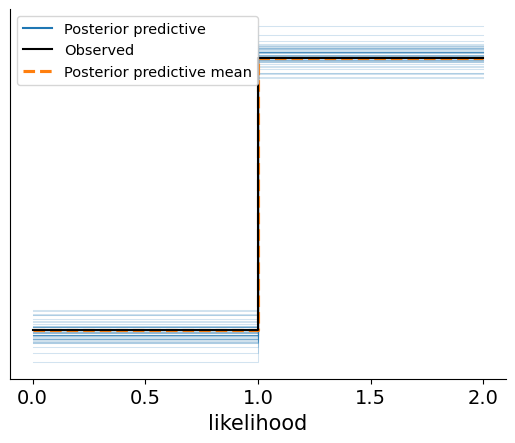

In [37]:
az.plot_ppc(log_model1_ppc, num_pp_samples=50)

sns.despine()

### 组合真实数据与预测数据  

* 我们可以将后验预测得到的分类结果(储存在`posterior_predictive.likelihood`中)全部提出  

* 并且对于每一个自变量，计算其后验分类结果的均值，相当于后验分类结果为 1 的比例  

* 结合分类标准，生成新的预测结果

In [38]:
log_model1_ppc.posterior_predictive.likelihood.stack(sample = ("chain", "draw"))

<xarray.DataArray 'likelihood' (likelihood_dim_2: 543, sample: 20000)>
array([[0, 1, 0, ..., 1, 1, 0],
       [1, 1, 1, ..., 0, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [0, 1, 1, ..., 1, 1, 0]])
Coordinates:
  * likelihood_dim_2  (likelihood_dim_2) int64 0 1 2 3 4 ... 538 539 540 541 542
  * sample            (sample) object MultiIndex
  * chain             (sample) int64 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3
  * draw              (sample) int64 0 1 2 3 4 5 ... 4995 4996 4997 4998 4999

In [39]:
#stack(sample = ("chain", "draw")：将每一个X对应的4*5000个后验预测值合并到一个维度sample
#对于每一个X，需要计算其20000个值的平均值，因此将dim设置为sample
pred_pi = log_model1_ppc.posterior_predictive.likelihood.stack(sample = ("chain", "draw")).mean(dim="sample")

# 转换为数据框
pred_pi = pred_pi.to_dataframe()

In [41]:
#将原数据中的X 和Y存入数据框
pred_pi["percentCoherence"] = log_model1_ppc.constant_data.percentCoherence.values
pred_pi["correct"] = log_model1_ppc.observed_data.likelihood.values

#根据分类标准（50-50）生成最终的分类结果
pred_pi["correct_pred"] = np.where(pred_pi["likelihood"] >= 0.5, 1, 0)
pred_pi

,likelihood,percentCoherence,correct,correct_pred
likelihood_dim_2,,,,
0,0.69155,10,1,1
1,0.92455,40,0,1
2,0.92445,40,1,1
3,0.68570,10,1,1
4,0.68680,10,1,1
...,...,...,...,...
538,0.68575,10,1,1
539,0.68165,10,1,1
540,0.68810,10,1,1


### 评估分类结果  

* $Y$为每个自变量对应的二分因变量，$\hat{Y}$为对应的后验分类结果  
* 我们可以使用**混淆矩阵**(confusion matrix)来对真实结果与分类结果进行比较和评估  

    * a: 真阴性（True Negative，TN）表示被正确预测为负例的样本数  
    * b: 假阳性（False Positive，FP）表示被错误预测为正例的样本数  
    * c: 假阴性（False Negative，FN）表示被错误预测为负例的样本数  
    * d: 真阳性（True Positive，TP）表示被正确预测为正例的样本数  

|  | $\hat{Y} = 0$    | $\hat{Y} = 1$ |  
| --------  | -------- | -------- |  
| $Y=0$ | a | b |  
| $Y=1$ | c | d |

在二分类问题中，准确性（Accuracy）、敏感性（Sensitivity）和特异性（Specificity）是常用的评估指标，可以通过在得到 a b c d 的数量之后进行计算：  

1. **准确性(accuracy)** ：准确性是指分类模型正确预测的样本数占总样本数的比例。  
* 准确性衡量了模型总体的分类正确率，数值越高表示模型的整体性能越好。  

$$  
\text{accuracy} = \frac{(TP + TN)}{(TP + TN + FP + FN)} =\frac{a + d}{a + b + c + d}  
$$  

2. **敏感性(sensitivity)** ：敏感性也称为召回率（Recall），它是指在所有实际为正例的样本中，被正确预测为正例的比例。  
* 敏感性衡量了模型对于正例的识别能力，数值越高表示模型对于正例的预测能力越好。  
 $$  
 \text{sensitivity} = \frac{TP}{(TP + FN)} = \frac{d}{c + d}  
 $$  

3. **特异性(specificity)** ：特异性是指在所有实际为负例的样本中，被正确预测为负例的比例。  
* 特异性衡量了模型对于负例的识别能力，数值越高表示模型对于负例的预测能力越好。  
 $$  
 \text{specificity} = \frac{TN}{(TN + FP)} = \frac{a}{a + b}  
 $$

In [48]:
# 使用`pd.crosstab`生成混淆矩阵，前两个值表明你需要统计的列名
# 由于要生成一个2*2的联表，需要指定行的名称和列的名称
confusion_matrix = pd.crosstab(pred_pi["correct"], pred_pi["correct_pred"], 
                              rownames=['Actual'], colnames=['Predicted'])
confusion_matrix

Predicted,1
Actual,
0,102
1,441


In [ ]:
# 计算各类指标
true_positive = confusion_matrix.at[1, 1] if 1 in confusion_matrix.index and 1 in confusion_matrix.columns else 0
false_positive = confusion_matrix.at[0, 1] if 0 in confusion_matrix.index and 1 in confusion_matrix.columns else 0
true_negative = confusion_matrix.at[0, 0] if 0 in confusion_matrix.index and 0 in confusion_matrix.columns else 0
false_negative = confusion_matrix.at[1, 0] if 1 in confusion_matrix.index and 0 in confusion_matrix.columns else 0

# 打印结果
print(f"True Positive: {true_positive}")
print(f"False Positive: {false_positive}")
print(f"True Negative: {true_negative}")
print(f"False Negative: {false_negative}")

# 计算其他指标
accuracy = (true_positive + true_negative) / (true_positive + false_positive + true_negative + false_negative)
sensitivity = true_positive / (true_positive + false_negative) if (true_positive + false_negative) != 0 else 0
specificity = true_negative / (true_negative + false_positive) if (true_negative + false_positive) != 0 else 0

print(f"准确性: {accuracy}")
print(f"敏感性: {sensitivity}")
print(f"特异性: {specificity}")

Predicted    1
Actual        
0          102
1          441
True Positive: 441
False Positive: 102
True Negative: 0
False Negative: 0
准确性: 0.8121546961325967
敏感性: 1.0
特异性: 0.0


## 总结  

本节课学习了如何通过广义线性模型(Generalized linear model, GLM)拟合二元决策变量。  

重点在于：  
- 了解二元决策变量适合的分布，伯努利(Bernoulli)分布。  
- 了解如何通过概率、发生率和链接函数(link function)来表示线性模型。  
- 学习模型评估指标：准确性（Accuracy）、敏感性（Sensitivity）和特异性（Specificity）。

## 补充：使用bambi建立logistic回归模型 

这里我们使用 bambi 提供的默认先验来构建模型。 可以看到：
* 先验为：
    
    Intercept ~ Normal(mu: 0.0, sigma: 3.6269)
    
    C(percentCoherence) ~ Normal(mu: 0.0, sigma: 5.0062)
* 模型分布为：bernoulli
* 链接函数为：p = logit
* `C(percentCoherence)` 代表将 percentCoherence 变量编码为分类变量 (categorical variable)。

In [52]:
def inv_logit(log_odds):
    return np.exp(log_odds) / (1 + np.exp(log_odds))

In [53]:
import bambi as bmb

bambi_logit = bmb.Model("correct ~ C(percentCoherence)", df_clean, family="bernoulli")
bambi_logit

       Formula: correct ~ C(percentCoherence)
        Family: bernoulli
          Link: p = logit
  Observations: 543
        Priors: 
    target = p
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 3.6269)
            C(percentCoherence) ~ Normal(mu: 0.0, sigma: 5.0062)

**模型拟合**

这里使用 bambi 提供的默认拟合设置。
* 包括 4 条 MCMC 链，每个链 2000 个迭代，其中前 1000 个为 burn-in 阶段。

In [54]:
model_fitted = bambi_logit.fit(random_seed=84735)

Modeling the probability that correct==1
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, C(percentCoherence)]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


In [58]:
model_fitted

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [55]:
fitted_parameters = az.summary(model_fitted)
fitted_parameters

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
C(percentCoherence)[40],1.764,0.267,1.232,2.218,0.006,0.004,2328.0,2307.0,1.0
Intercept,0.783,0.134,0.531,1.027,0.002,0.002,3322.0,3109.0,1.0


In [56]:
p_coh10 = inv_logit( fitted_parameters.loc["Intercept", "mean"])
p_coh40 = inv_logit( 
    fitted_parameters.loc["Intercept", "mean"] + \
        fitted_parameters.loc["C(percentCoherence)[40]", "mean"]
)

print(f"p(coherence=10) = {p_coh10:.3f}", f"p(coherence=40) = {p_coh40:.3f}")

p(coherence=10) = 0.686 p(coherence=40) = 0.927


In [ ]:
posterior_predictive = bambi_logit.predict(model_fitted, kind="pps")
model_fitted

<Axes: xlabel='correct'>

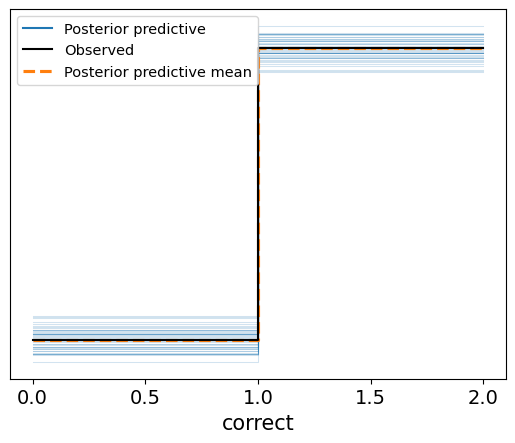

In [ ]:
az.plot_ppc(model_fitted, num_pp_samples=50)
sns.despine()

## 练习  

我们以一个新的例子进行练习对logistic模型的使用。 

我们关注的研究问题：**个体依恋风格中的回避倾向**如何影响个体的**恋爱情况**？  

* 成人依恋量表是一种常用于评估个体依恋风格的工具，包括亲密关系中的情感需求和行为模式。其中的回避分数反映了个体在恋爱关系中表现出的回避特征。这些特征通常表现为对亲密关系的回避、不愿意与伴侣建立过多的情感联系、保持独立性和独立思考的倾向。  

* 研究假设：具有高回避分数的个体可能更倾向于避免或抵制与伴侣建立深入的情感联系，更难以建立恋爱关系  

* 在此示例研究中，我们使用成人依恋量表中的分量表测得回避分数，并使用标准化后的回避分数进行后续分析。  

> * 数据来源: Hu, C.-P. et al. (2018). Raw data from the Human Penguin Project. Open Science Framework. https://doi.org/10.17605/OSF.IO/H52D3  
> * 回避分数量表来源：Fraley, R. C., Waller, N. G. & Brennan, K. A. An item response theory analysis of self-report measures of adult attachment. J. Pers. Soc. Psychol. 78, 350–365 (2000).





* 我们对以下关键步骤进行练习  
    * 模型定义  
    * 绘制后验预测回归线  
    * 对新数据进行预测  
    * 后验预测评估  


### 可视化

In [5]:
# 导入 pymc 模型包，和 arviz 等分析工具 
import pymc as pm
import arviz as az
import seaborn as sns
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import ipywidgets

# 忽略不必要的警告
import warnings


In [6]:
df_raw = pd.read_csv('2024/data/Data_Sum_HPP_Multi_Site_Share.csv')

# 通过 pd.read_csv 加载数据 Data_Sum_HPP_Multi_Site_Share.csv
# try:
#   df_raw = pd.read_csv('/home/mw/input/bayes20238001/Data_Sum_HPP_Multi_Site_Share.csv')
# except:
#   df_raw = pd.read_csv('data/Data_Sum_HPP_Multi_Site_Share.csv')

# 选取清华站点的数据
df = df_raw[df_raw["Site"] == "Tsinghua"]

# 选取本节课涉及的变量
df = df[["romantic", "avoidance_r", "sex"]]

#重新编码，编码后的数据：1 = "yes"; 2 = "no"
df["romantic"] =  np.where(df['romantic'] == 2, 0, 1)

#设置索引
df["index"] = range(len(df))
df = df.set_index("index")
warnings.filterwarnings("ignore")

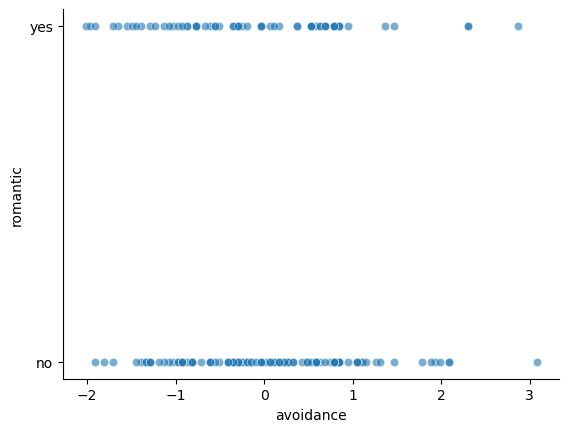

In [7]:
# 绘制散点图
sns.scatterplot(data=df,
                x="avoidance_r",
                y="romantic",
                alpha=0.6)
# 设置x轴标题
plt.xlabel("avoidance")
# 设置y轴刻度
plt.yticks([0,1],['no','yes'])
sns.despine()

## 模型定义  

$$  
\begin{array}{lcrl}  
\text{data:} & \hspace{.01in} & Y_i|\beta_0,\beta_1 & \stackrel{ind}{\sim} \text{Bern}(\pi_i) \;\; \text{ with } \;\; \pi_i = \frac{e^{\beta_0 + \beta_1 X_{i1}}}{1 + e^{\beta_0 + \beta_1 X_{i1}}} \\  
\text{priors:} & & \beta_{0}  &  \sim N\left(0, 0.5^2 \right)  \\  
               & & \beta_1  & \sim N\left(0, 0.5^2 \right)\\  
\end{array}  
$$

In [9]:
##---------------------------------------------------------------------------
#      提示：参照之前的代码与先验定义，对...中的内容进行修改
#---------------------------------------------------------------------------
with pm.Model() as log_model2:
    log_model1.add_coord('obs_id',df.index, mutable=True)
    avoidance = pm.MutableData("avoidance", df.avoidance_r, dims="obs_id")
    y = pm.MutableData('y', df.romantic, dims = 'obs_id')

    #先验
    beta_0 = pm.Normal("beta_0", mu=0, sigma=0.5)          #定义beta_0          
    beta_1 = pm.Normal("beta_1", mu=0, sigma=0.5)           #定义beta_1
    #线性关系
    mu = pm.Deterministic("mu", beta_0 + beta_1 * avoidance, dims="obs_id")
    #注意此处使用了Logistic sigmoid function：pm.math.invlogit
    #相当于进行了如下计算 (1 / (1 + exp(-mu))
    pi = pm.Deterministic("pi", pm.math.invlogit(mu), dims="obs_id")
    #似然
    likelihood = pm.Bernoulli("y_est",p=pi, observed=y,dims="obs_id")

### MCMC采样

In [10]:
#===========================
#     注意！！！以下代码可能需要运行1-2分钟左右
#===========================
with log_model2:
    # MCMC 近似后验分布
    log_model2_trace = pm.sample(
                                draws=5000,                   # 使用mcmc方法进行采样，draws为采样次数
                                tune=1000,                    # tune为调整采样策略的次数，可以决定这些结果是否要被保留
                                chains=4,                     # 链数
                                discard_tuned_samples= True,  # tune的结果将在采样结束后被丢弃
                                random_seed=84735)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta_1]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 2 seconds.


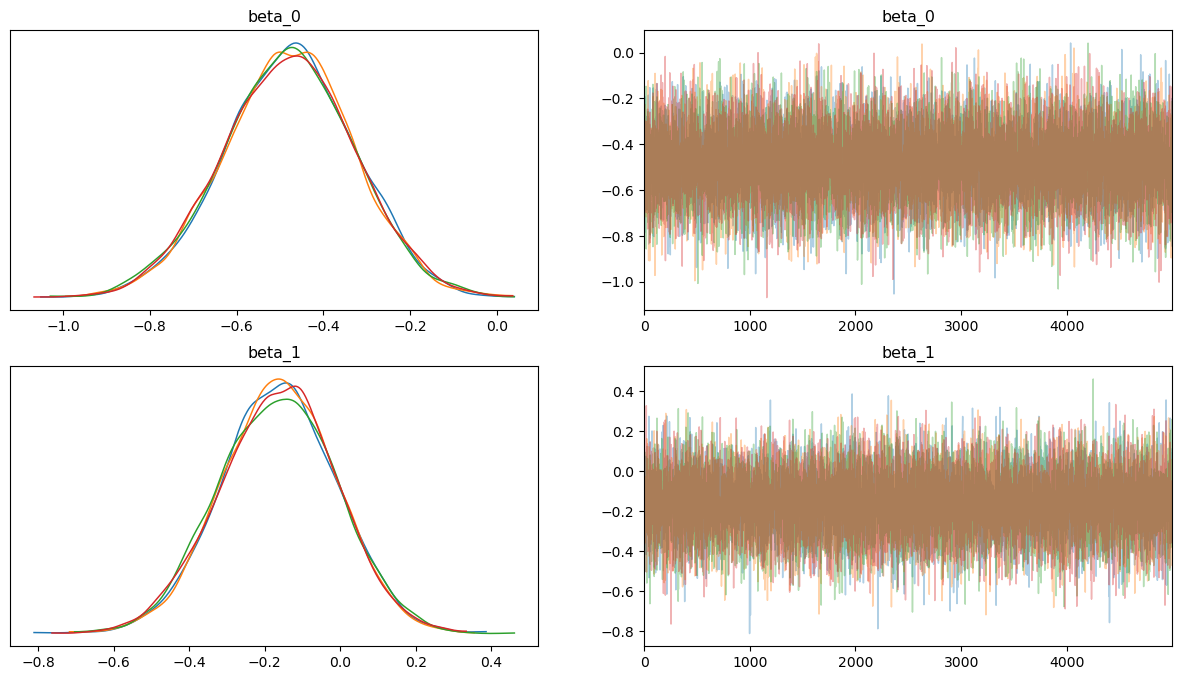

In [12]:
az.plot_trace(log_model2_trace,
              var_names=["beta_0","beta_1"],
              figsize=(15,8),
              compact=False)
plt.show()

### 绘制后验预测回归线

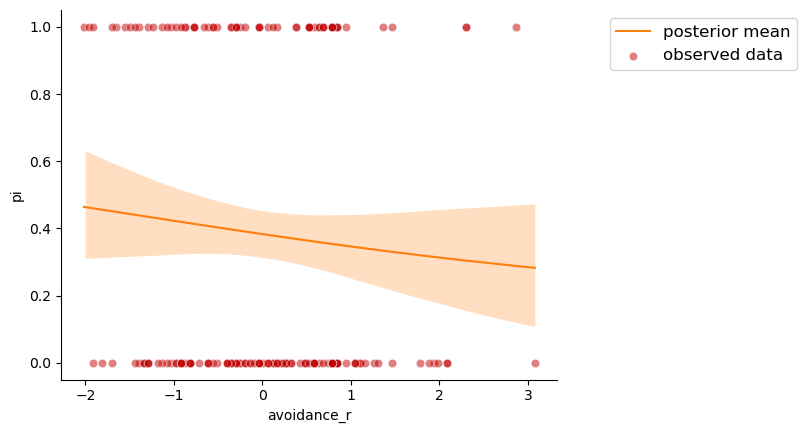

In [14]:
##---------------------------------------------------------------------------
#      提示：参照之前的代码与先验定义，对...中的内容进行修改
#---------------------------------------------------------------------------


#画出每个自变量对应的恋爱概率94%hdi值
az.plot_hdi(
    df.avoidance_r,
    log_model2_trace.posterior.pi,
    hdi_prob=0.95,
    fill_kwargs={"alpha": 0.25, "linewidth": 0},
    color="C1"
)
#得到每个自变量对应的恋爱概率均值，并使用sns.lineplot连成一条光滑的曲线
post_mean = log_model2_trace.posterior.pi.mean(("chain", "draw"))
sns.lineplot(x = df.avoidance_r, 
             y= post_mean, 
             label="posterior mean", 
             color="C1")
#绘制真实数据散点图
sns.scatterplot(x = df.avoidance_r, 
                y= df.romantic,label="observed data", 
                color='#C00000', 
                alpha=0.5)
#设置图例位置
plt.legend(loc="upper right",
           bbox_to_anchor=(1.5, 1),
           fontsize=12)
sns.despine()

### 对新数据进行预测&分类

In [16]:
##---------------------------------------------------------------------------
#      提示：参照之前的代码与先验定义，对...中的内容进行修改
#---------------------------------------------------------------------------

pred_coords ={"obs_id":range(174,175)} 

with log_model2:
    # 传入数据
    pm.set_data({"avoidance": np.array([1]),
                 "y": np.array([0])},
                coords=pred_coords
                )   
    # 生成对因变量的预测
    prediction = pm.sample_posterior_predictive(log_model2_trace, 
                                                var_names=["y_est"],
                                                predictions=True,
                                                extend_inferencedata=True,
                                                random_seed=84735)

Sampling: [y_est]


Output()

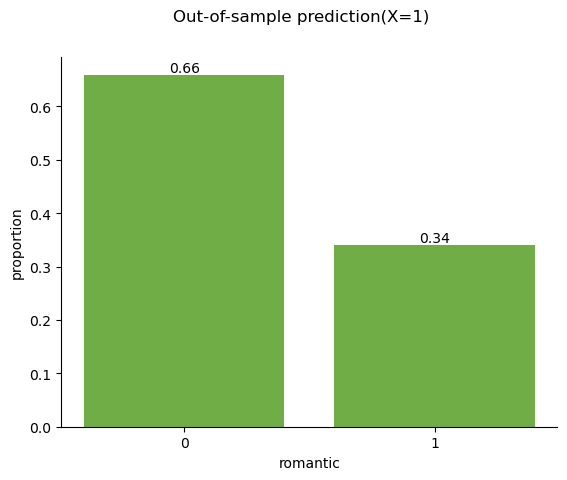

In [17]:
##---------------------------------------------------------------------------
#      提示：参照之前的代码与先验定义，对...中的内容进行修改
#---------------------------------------------------------------------------

# 提取储存在 predicitons中的预测值
y_pred = prediction.predictions["y_est"].stack(sample=("chain","draw","obs_id")).values
# 统计其中0和1的个数，并除以总数，得到0和1对应的比例值
y_pred_freq = np.bincount(y_pred)/len(y_pred)
#绘制柱状图
bars = plt.bar([0, 1], y_pred_freq, color="#70AD47")
#用于在柱状图上标明比例值
for bar, freq in zip(bars, y_pred_freq):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{freq:.2f}", ha='center', va='bottom')
#对刻度、标题、坐标轴标题进行设置
plt.xticks([0, 1])
plt.suptitle("Out-of-sample prediction(X=1)")
plt.xlabel("romantic")
plt.ylabel("proportion")
sns.despine()

### 后验预测评估

In [18]:
coords = {"obs_id": df.index}

with pm.Model(coords=coords) as log_model2:
    avoidance = pm.MutableData("avoidance", df.avoidance_r, dims="obs_id")

    #先验
    beta_0 = pm.Normal("beta_0", mu=0, sigma=0.5)          #定义beta_0          
    beta_1 = pm.Normal("beta_1", mu=0, sigma=0.5)           #定义beta_1
    #线性关系
    mu = pm.Deterministic("mu", beta_0 + beta_1 * avoidance, dims="obs_id")
    pi = pm.Deterministic("pi", pm.math.invlogit(mu), dims="obs_id")
    #似然
    likelihood = pm.Bernoulli("y_est",p=pi, observed=df.romantic,dims="obs_id")

    log_model2_trace = pm.sample(draws=5000,                 
                                tune=1000,                  
                                chains=4,                     
                                discard_tuned_samples= True, 
                                random_seed=84735)
    log_model2_ppc = pm.sample_posterior_predictive(log_model2_trace)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_0, beta_1]


Output()

Sampling 4 chains for 1_000 tune and 5_000 draw iterations (4_000 + 20_000 draws total) took 3 seconds.
Sampling: [y_est]


Output()

In [20]:
#stack(sample = ("chain", "draw")：将每一个X对应的4*5000个后验预测值合并到一个维度sample
#对于每一个X，需要计算其20000个值的平均值，因此将dim设置为sample
pred_pi = log_model2_ppc.posterior_predictive.y_est.stack(sample = ("chain", "draw")).mean(dim="sample")
# 转换为数据框
pred_pi = pred_pi.to_dataframe()

In [21]:
##---------------------------------------------------------------------------
#      提示：参照之前的代码与先验定义，对...中的内容进行修改
#---------------------------------------------------------------------------

#将原数据中的X 和Y存入数据框
pred_pi["avoidance"] = log_model2_ppc.constant_data.avoidance.values
pred_pi["romantic"] = log_model2_ppc.observed_data.y_est.values

#根据分类标准（50-50）生成最终的分类结果
pred_pi["romantic_pred"] = np.where(pred_pi["y_est"] >= 0.5, 1, 0)
pred_pi

,y_est,avoidance,romantic,romantic_pred
obs_id,,,,
0,0.35485,0.843130,0,0
1,0.40305,-0.612479,0,0
2,0.43320,-1.288297,0,0
3,0.37010,0.479227,0,0
4,0.40160,-0.612479,1,0
...,...,...,...,...
169,0.37550,0.167311,0,0
170,0.36105,0.583200,0,0
171,0.38180,-0.040633,0,0


In [22]:
# 使用`pd.crosstab`生成混淆矩阵，前两个值表明你需要统计的列名
# 由于要生成一个2*2的联表，需要指定行的名称和列的名称
confusion_matrix = pd.crosstab(pred_pi["romantic"], pred_pi["romantic_pred"], 
                              rownames=['Actual'], colnames=['Predicted'])
confusion_matrix

Predicted,0
Actual,
0,109
1,65


In [23]:
##---------------------------------------------------------------------------
#      提示：参照之前的代码与先验定义，对...中的内容进行修改
#---------------------------------------------------------------------------

# 计算a b c d的数量
true_positive = 0
false_positive = 0
true_negative = confusion_matrix.at[0, 0]
false_negative = confusion_matrix.at[1, 0]
# 代入公式
accuracy = (true_positive + false_negative) /(true_positive + false_positive + true_negative + false_negative)
sensitivity = (true_positive) /(true_positive + false_negative)
specificity = (true_negative) / (true_negative + false_positive)

print("准确性:", accuracy)
print("敏感性:", sensitivity)
print("特异性:", specificity)

准确性: 0.3735632183908046
敏感性: 0.0
特异性: 1.0
